In [1]:
import matplotlib.pyplot as plt

from imagematerials.rest_of.metals_projections import (
    steel_projection, 
    aluminium_projection, 
    copper_projection)

from imagematerials.rest_of.preprocessing.regressions_all_materials import *

from imagematerials.rest_of.water import water_consumption

from imagematerials.rest_of.biomass import biomass_data

from imagematerials.rest_of.fossil_fuels import fossil_fuel_data

from imagematerials.rest_of.nmm_projections import (cement_projection, 
                                                    sand_projections, 
                                                    limestone_projection,
                                                    clay_projections) 

from pathlib import Path


In [2]:
results = fit_models_all_materials()
make_gompertz_coefs_da(results)
historic_other_fraction_comsumption_to_xr(results)

SSP2_M_CP


In [3]:
# Run IMAGE Materials projections
scenario_list = {"SSP2_M_CP":("SSP2_M_CP",["base"]),
                 "SSP2_VLLO":("SSP2_VLLO",["base"]),
                 "SSP2_VLLO_LifeTech":("SSP2_VLLO_LifeTech",["base"])}

scenario_base_path = Path("../../../data/raw") / 'RO_scenarios'

In [4]:
results = {}

for scenario in scenario_list.keys():
    print(scenario)
    # Run all projections for this scenario
    copper = copper_projection(scenario=scenario)
    steel = steel_projection(scenario=scenario)
    aluminium = aluminium_projection(scenario=scenario)
    cement = cement_projection(scenario=scenario)
    sand = sand_projections(scenario=scenario)
    limestone = limestone_projection(scenario=scenario)
    clay = clay_projections(scenario=scenario)
    biomass = biomass_data(scenario=scenario)
    fossil_fuel = fossil_fuel_data(scenario=scenario)
    water = water_consumption(scenario=scenario)
    
    # Store model objects or just their outputs
    results[scenario] = {
        'copper': copper,
        'steel': steel,
        'aluminium': aluminium,
        'cement': cement,
        'sand': sand,
        'limestone': limestone,
        'clay': clay,
        'biomass': biomass,
        'fossil_fuel': fossil_fuel,
        'water': water
    }

SSP2_M_CP


FileNotFoundError: [Errno 2] No such file or directory: '../../../data/raw/rest-of/IMAGE_MAT_out/SSP2_CP/material_output_buma_RASMI.csv'

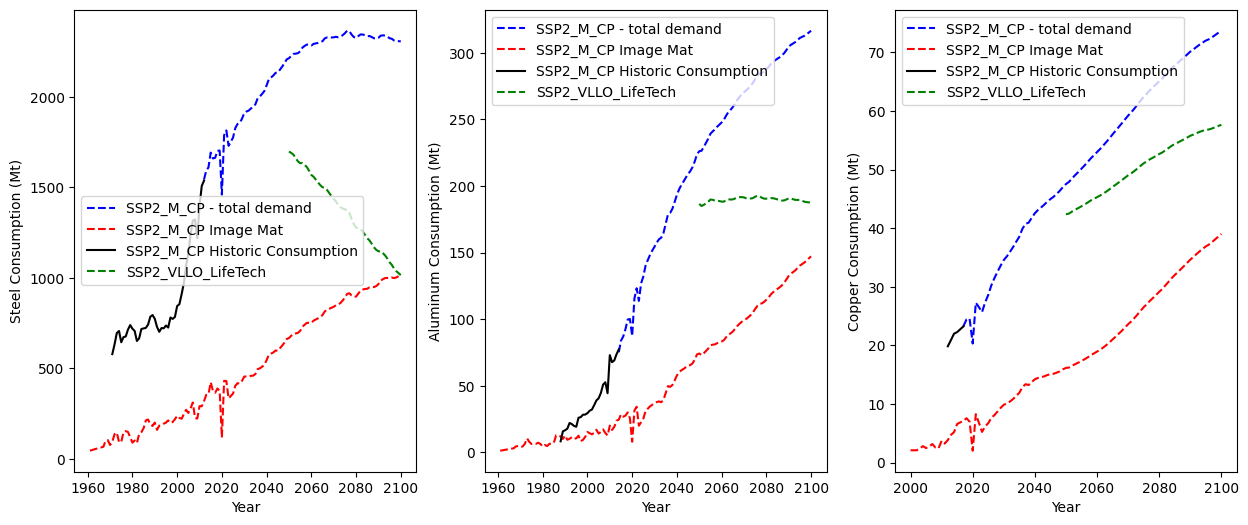

In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['steel'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax1.plot((results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['aluminium'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



In [ ]:
results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne

1988     8.385000
1989    15.847755
1990    16.712112
1991    17.850518
1992    22.159968
1993    21.348793
1994    19.923146
1995    19.326651
1996    26.075613
1997    26.553336
1998    28.355530
1999    28.482603
2000    29.557011
2001    31.394370
2002    32.264342
2003    35.507376
2004    39.064289
2005    40.686877
2006    44.686877
2007    50.968931
2008    52.733059
2009    44.517381
2010    73.087085
2011    67.813888
2012    69.126328
2013    73.741405
2014    77.364109
dtype: float64

In [ ]:
results['SSP2_M_CP'].get('steel').region_model_match

{'class_ 1': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b2481c4c50>,
 'class_ 2': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b24818a3f0>,
 'class_ 3': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b248189d90>,
 'class_ 4': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b2481c5400>,
 'class_ 5': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b248189d90>,
 'class_ 6': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b248189d90>,
 'class_ 7': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b248189d90>,
 'class_ 8': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b2481c5400>,
 'class_ 9': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b2481c5400>,
 'class_ 10': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x1b2481c7350>,
 'class_ 11': <imagematerials

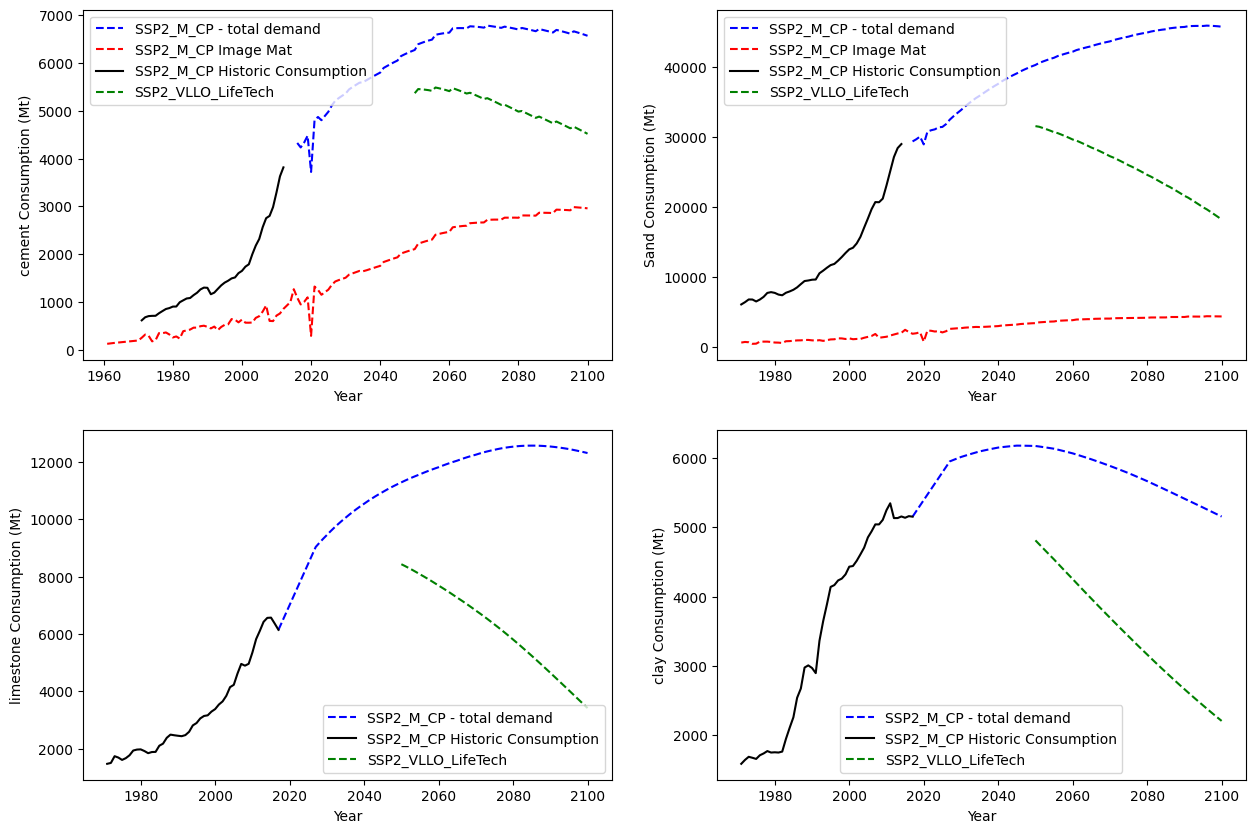

In [ ]:
# Plot nmm base scenario (SSP2_M_CP) with historic data

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharey=False)
ax1, ax2, = axes[0]
ax3, ax4 = axes[1]

ax1.plot(results['SSP2_M_CP']['cement'].projection_per_region_total.sum(axis=1).loc[2016:]/tonne_to_megatonne + results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[2016:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['cement'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax1.plot((results['SSP2_M_CP']['cement'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['cement'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('cement Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['sand'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['sand'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['sand'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['sand'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax2.set_xlabel('Year')
ax2.set_ylabel('Sand Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['limestone'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['limestone'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['limestone'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')



ax3.set_xlabel('Year')
ax3.set_ylabel('limestone Consumption (Mt)')
ax3.legend()


ax4.plot(results['SSP2_M_CP']['clay'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax4.plot(results['SSP2_M_CP']['clay'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax4.plot((results['SSP2_M_CP']['clay'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax4.set_xlabel('Year')
ax4.set_ylabel('clay Consumption (Mt)')
ax4.legend()


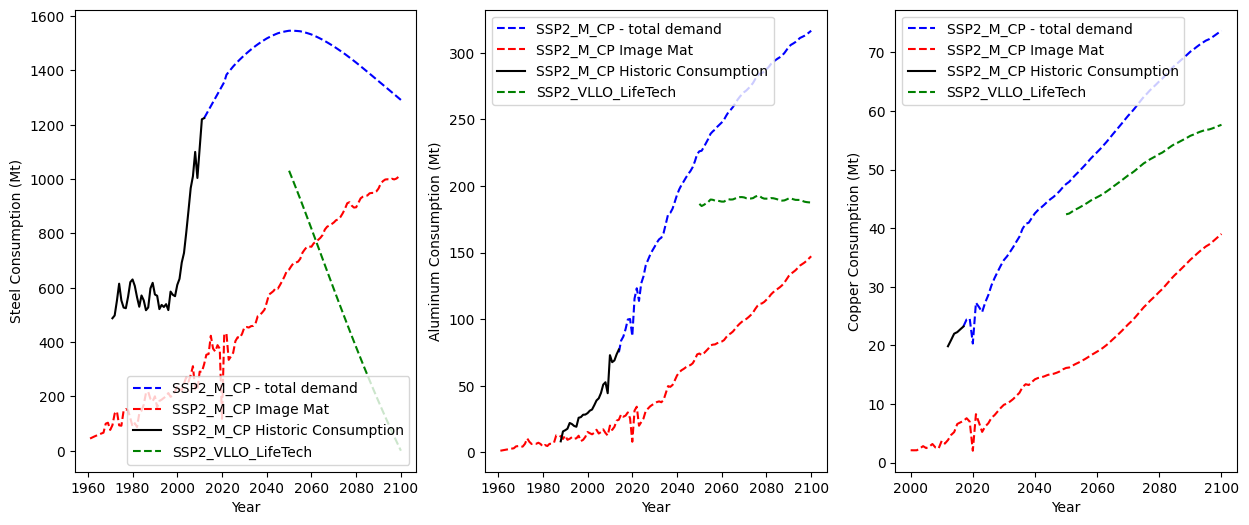

In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
         label='SSP2_M_CP - total demand', color='blue', linestyle='--') 

ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')

ax1.plot(results['SSP2_M_CP']['steel'].historic_other_fraction_consumption.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne,
          linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax1.set_xlabel('Year')
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax2.plot((results['SSP2_M_CP']['aluminium'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')
ax3.plot((results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne + 
          results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne)
         , linestyle='--', label ='SSP2_VLLO_LifeTech', color='green')


ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



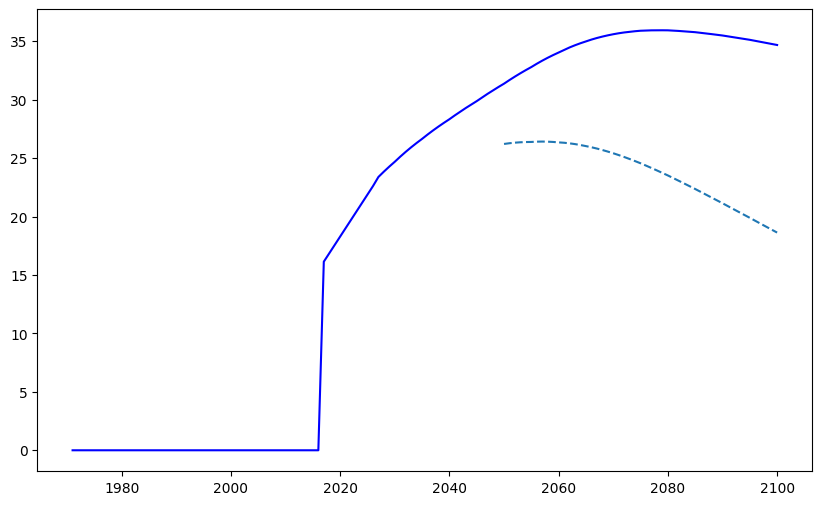

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha.loc[2050:, ].sum(axis=1)/tonne_to_megatonne, linestyle='--')
ax.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1)/tonne_to_megatonne, label='SSP2_M_CP - total demand', color='blue')


In [ ]:
results['SSP2_M_CP']['copper'].projection_per_region_adapted_alpha

,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2096,586828.832806,761337.971020,833035.094322,1.670096e+06,3.871783e+06,1.814190e+06,6.959574e+06,85827.771362,2.790954e+06,162603.637241,99843.495940
2097,579216.136493,761007.551605,820403.535564,1.666352e+06,3.823376e+06,1.744623e+06,6.902104e+06,85776.150344,2.746763e+06,156856.527781,96028.523995
2098,571634.638548,760676.945090,807854.659025,1.662608e+06,3.775136e+06,1.676099e+06,6.844158e+06,85724.529327,2.702888e+06,151174.255994,92270.187570
2099,564083.993018,760346.338575,795388.275589,1.658864e+06,3.727062e+06,1.608619e+06,6.785775e+06,85672.908310,2.659328e+06,145556.821880,88568.467353


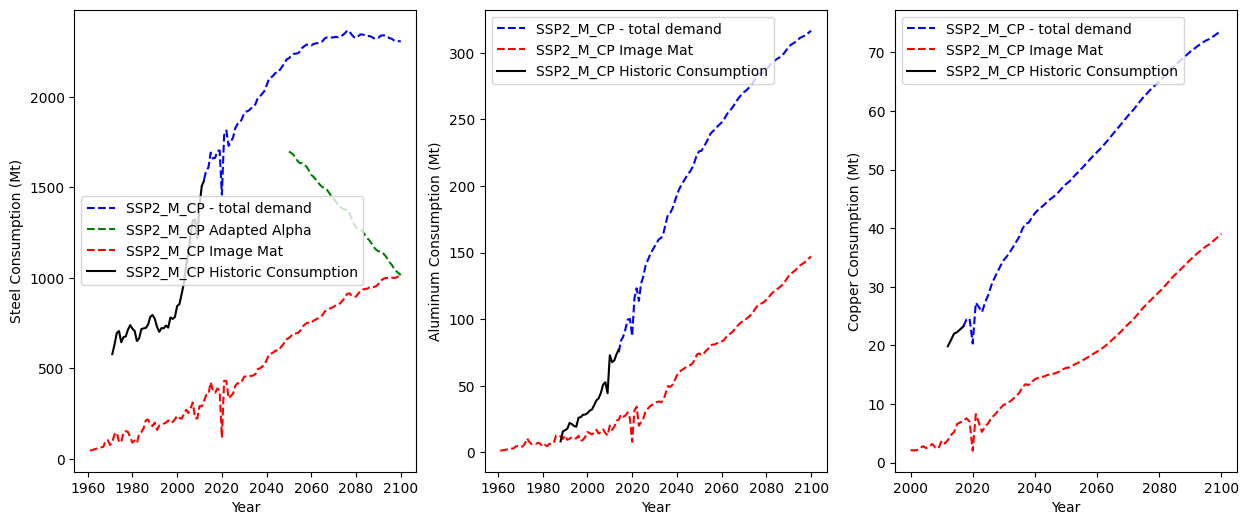

In [ ]:
# Plot metal base scenario (SSP2_M_CP) with historic data

tonne_to_megatonne = 1e6

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=False)
ax1, ax2, ax3 = axes
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_total.sum(axis=1).loc[2012:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2012:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax1.plot(results['SSP2_M_CP']['steel'].projection_per_region_adapted_alpha.sum(axis=1).loc[2050:]/tonne_to_megatonne + results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[2050:]/tonne_to_megatonne
         , label='SSP2_M_CP Adapted Alpha', linestyle='--', color='green')
ax1.plot(results['SSP2_M_CP']['steel'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax1.plot(results['SSP2_M_CP']['steel'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

# x axis title
ax1.set_xlabel('Year')
# y axis title
ax1.set_ylabel('Steel Consumption (Mt)')
ax1.legend()


ax2.plot(results['SSP2_M_CP']['aluminium'].projection_per_region_total.sum(axis=1).loc[2014:]/tonne_to_megatonne + results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[2014:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax2.plot(results['SSP2_M_CP']['aluminium'].image_mat_data.sum(axis=1).loc[1960:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax2.plot(results['SSP2_M_CP']['aluminium'].historic_consumption_data.sum(axis=1).loc[:2014]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax2.set_xlabel('Year')
ax2.set_ylabel('Aluminum Consumption (Mt)')
ax2.legend()


ax3.plot(results['SSP2_M_CP']['copper'].projection_per_region_total.sum(axis=1).loc[2017:]/tonne_to_megatonne + results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2017:]/tonne_to_megatonne, 
        label='SSP2_M_CP - total demand', color='blue', linestyle='--') 
ax3.plot(results['SSP2_M_CP']['copper'].image_mat_data.sum(axis=1).loc[2000:]/tonne_to_megatonne, label='SSP2_M_CP Image Mat', linestyle='--', color='red')
ax3.plot(results['SSP2_M_CP']['copper'].historic_consumption_data.sum(axis=1).loc[:]/tonne_to_megatonne, label='SSP2_M_CP Historic Consumption', color='black')

ax3.set_xlabel('Year')
ax3.set_ylabel('Copper Consumption (Mt)')
ax3.legend()



In [ ]:
results['SSP2_M_CP']['fossil_fuel']['fossils_primary'] - results['SSP2_VLLO_LifeTech']['fossil_fuel']['fossils_primary']

DIM_1              1          2           3           4           5   \
time DIM_2                                                             
1971 1         0.0000      0.000     0.00000     0.00000     0.00000   
     2         0.0000      0.000     0.00000     0.00000     0.00000   
     4         0.0000      0.000     0.00000     0.00000     0.00000   
1972 1         0.0000      0.000     0.00000     0.00000     0.00000   
     2         0.0000      0.000     0.00000     0.00000     0.00000   
...               ...        ...         ...         ...         ...   
2099 2      1161.3484  11728.264  2823.71820  1355.38520  3176.29200   
     4      2274.2270  12619.963  2677.07340  1335.84620  4625.92040   
2100 1        61.9740    215.429    80.66693  2736.60183   132.64021   
     2      1165.1321  11607.296  2752.85440  1347.99420  3068.96270   
     4      2300.2720  13019.232  2666.50650  1363.49620  4774.01780   

DIM_1              6            7          8           9           10  ...  \
time DIM_2                                                             ...   
1971 1         0.0000      0.00000      0.000     0.00000     0.00000  ...   
     2         0.0000      0.00000      0.000     0.00000     0.00000  ...   
     4         0.0000      0.00000      0.000     0.00000     0.00000  ...   
1972 1         0.0000      0.00000      0.000     0.00000     0.00000  ...   
     2         0.0000      0.00000      0.000     0.00000     0.00000  ...   
...               ...          ...        ...         ...         ...  ...   
2099 2      2420.1922   7565.84400   6206.694  3129.73600  1178.89350  ...   
     4      5932.5631  11602.30820  23685.924  7886.09600  1414.67587  ...   
2100 1       117.0513     91.45381   4104.386  1306.00196   860.01272  ...   
     2      2359.1790   7515.12580   6313.711  3063.22100  1176.79480  ...   
     4      6051.9165  11462.16760  24059.393  8253.67500  1437.33061  ...   

DIM_1                19          20           21         22          23  \
time DIM_2                                                                
1971 1         0.000000      0.0000      0.00000     0.0000     0.00000   
     2         0.000000      0.0000      0.00000     0.0000     0.00000   
     4         0.000000      0.0000      0.00000     0.0000     0.00000   
1972 1         0.000000      0.0000      0.00000     0.0000     0.00000   
     2         0.000000      0.0000      0.00000     0.0000     0.00000   
...                 ...         ...          ...        ...         ...   
2099 2       646.940800  13880.8910   8032.49450  4403.5600  1145.11000   
     4      1588.080800  18809.6710   7124.16610  4283.1191  1845.75880   
2100 1       227.992367   6050.7145  12573.66798   386.4124   889.39513   
     2       650.308500  13645.4190   7937.50060  4340.4000  1149.85780   
     4      1611.052300  19073.3240   7108.74160  4324.5912  1822.58770   

DIM_1               24          25          26   27          28  
time DIM_2                                                       
1971 1         0.00000      0.0000     0.00000  0.0       0.000  
     2         0.00000      0.0000     0.00000  0.0       0.000  
     4         0.00000      0.0000     0.00000  0.0       0.000  
1972 1         0.00000      0.0000     0.00000  0.0       0.000  
     2         0.00000      0.0000     0.00000  0.0       0.000  
...                ...         ...         ...  ...         ...  
2099 2       920.61120   9370.5910  6331.11100  0.0  134164.580  
     4      3091.99390  20696.0350  7700.67980  0.0  208831.720  
2100 1        24.66292  13758.8065   718.09773  0.0   75884.059  
     2       921.51710   9316.0320  6342.08100  0.0  132996.100  
     4      3113.88910  21061.7590  8131.66920  0.0  211169.850  

[390 rows x 28 columns]

In [ ]:
year = 2050
scenario = 'SSP2_M_CP'
# convert fom petatonnes

fossil_fuels = results[scenario]['fossil_fuel']['fossils_primary_converted'].sum(axis = 1).loc[2050].sum() / 1e12  # Convert to megatonnes
fossil_fuels

np.float64(22.546905258014867)

KeyboardInterrupt: 

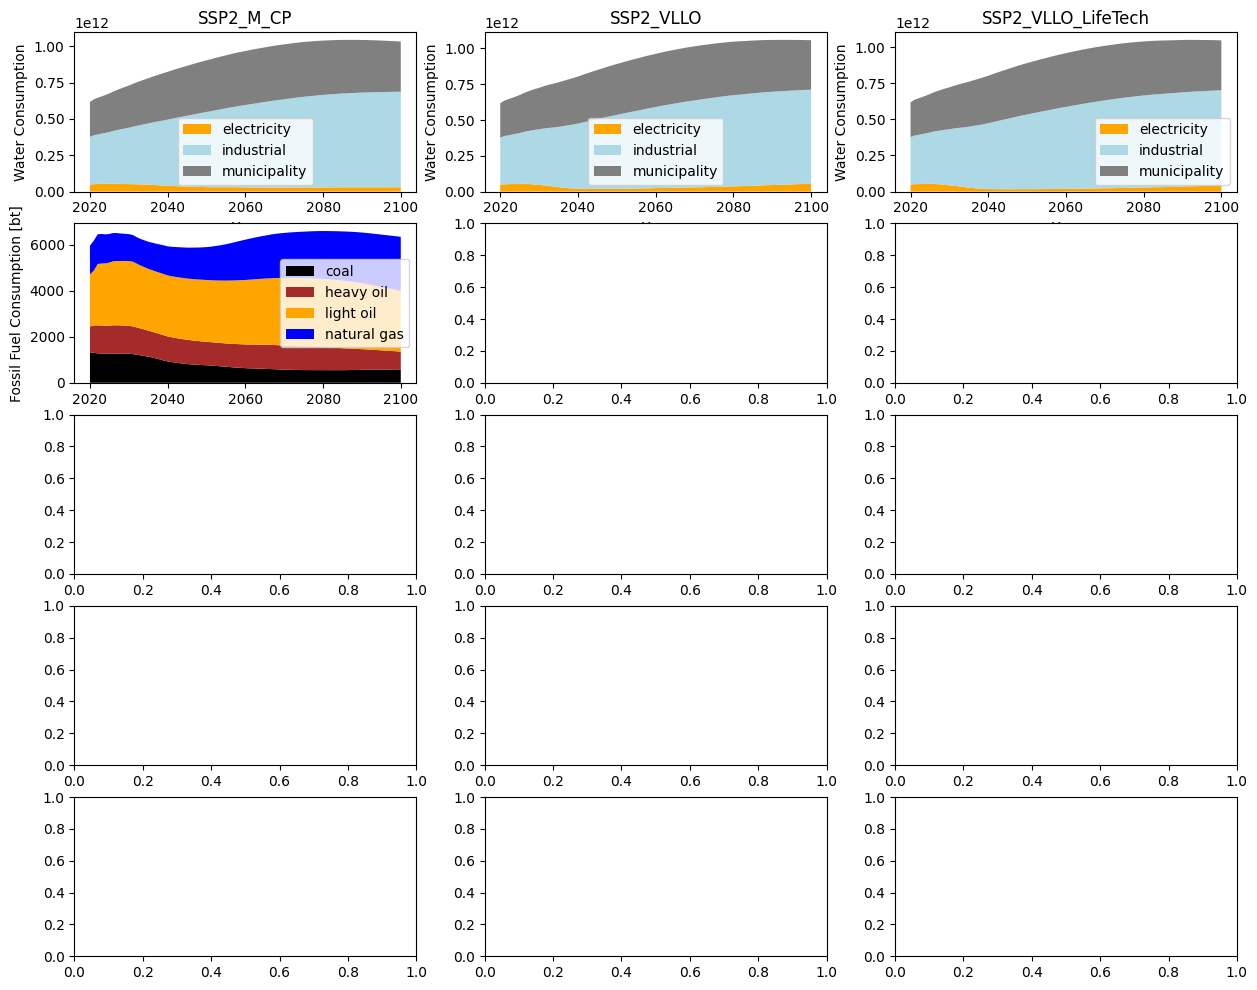

In [ ]:
import numpy as np
kg_to_billion_tonnes = 1e9

# Create a figure with 3 scenarios as columsn and 4 materials as rows
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12), sharey=False)
ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]
ax7, ax8, ax9 = axes[2]
ax10, ax11, ax12 = axes[3]
ax13, ax14, ax15 = axes[4]


# Scenario titles
for ax, scenario in zip([ax1, ax2, ax3], scenario_list):
    ax.set_title(scenario)

# Water consumption
for ax, scenario in zip(axes[0], scenario_list):
    ax.set_title(scenario)
    years = results[scenario]['water'][0].loc[2020:].index
    electricity = results[scenario]['water'][0].sum(axis=1).loc[2020:]
    industrial  = results[scenario]['water'][1].sum(axis=1).loc[2020:]
    municipality= results[scenario]['water'][2].sum(axis=1).loc[2020:]
    ax.stackplot(
        years,
        electricity,
        industrial,
        municipality,
        labels=['electricity', 'industrial', 'municipality'],
        colors=['orange', 'lightblue', 'gray']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Water Consumption')
    ax.legend()

# Fossil fuel consumption
for ax, scenario in zip(axes[1], scenario_list):
    # define years as a numpy list from 2020 to 2100
    years = list(range(2020, 2101))
    coal = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('coal').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    heavy_oil = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('heavy oil').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    light_oil = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('light oil').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    natural_gas = results[scenario]['fossil_fuel'].get('fossils_final_converteted').get('natural gas').query("DIM_2 == 10").sum(axis=1).loc[2020:]/kg_to_billion_tonnes
    ax.stackplot(
        years,
        coal,
        heavy_oil,
        light_oil,
        natural_gas,
        labels=['coal', 'heavy oil', 'light oil', 'natural gas'],
        colors=['black', 'brown', 'orange', 'blue']
    )
    ax.set_ylabel('Fossil Fuel Consumption [bt]')
    ax.legend()

# Biomass consumption
for ax, scenario in zip(axes[2], scenario_list):

    crop_dict = results[scenario]['biomass'].get('consumption_in_categories')
    years = crop_dict[next(iter(crop_dict))].loc[2020:].index
    crop_names = list(crop_dict.keys())
    if 'total' in crop_names:
        crop_names.remove('total')
    crop_values = [crop_dict[name].loc[2020:, :26].sum(axis=1).values for name in crop_names]

    ax.stackplot(years, *crop_values, labels=crop_names)
    ax.set_xlabel('Year')
    ax.set_ylabel('Biomass Consumption [bt]')
    ax.set_ylim(0, 16)  
    ax.legend(loc='upper left')
    plt.tight_layout()

# Metals consumption
for ax, scenario in zip(axes[3], scenario_list):
    if scenario == 'SSP2_M_CP':
        steel = results[scenario]['steel'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['steel'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        aluminium = results[scenario]['aluminium'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['aluminium'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        copper = results[scenario]['copper'].projection_per_region_total.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['copper'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne

    else:
        steel = results[scenario]['steel'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['steel'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        aluminium = results[scenario]['aluminium'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['aluminium'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        copper = results[scenario]['copper'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:2060].values / tonne_to_megatonne + results[scenario]['copper'].image_mat_data.sum(axis=1).loc[2020:2060]/tonne_to_megatonne
        
    years = list(range(2020, 2061))
    ax.stackplot(
        years,
        steel,
        aluminium,
        copper,
        labels=['steel', 'aluminium', 'copper'],
        colors=['blue', 'orange', 'green']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Metals Consumption [Mt]')
    # set y limit
    ax.set_ylim(0, 4500) 
    ax.legend(loc='upper left')
    plt.tight_layout()


# NMM consumption
for ax, scenario in zip(axes[4], scenario_list):
    if scenario == 'SSP2_M_CP':
        sand = results[scenario]['sand'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        limestone = results[scenario]['limestone'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        clay = results[scenario]['clay'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        cement = results[scenario]['cement'].projection_per_region_total.sum(axis=1).loc[2020:].values / tonne_to_megatonne
    else:
        sand = results[scenario]['sand'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        limestone = results[scenario]['limestone'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        clay = results[scenario]['clay'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        cement = results[scenario]['cement'].projection_per_region_adapted_alpha.sum(axis=1).loc[2020:].values / tonne_to_megatonne
        
    years = list(range(2020, 2101))
    ax.stackplot(
        years,
        sand,
        limestone,
        clay,
        cement,
        labels=['sand', 'limestone', 'clay', 'cement'],
        colors=['blue', 'orange', 'green', 'brown']
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('NMM Consumption [Mt]')    
    # set y limit
    ax.set_ylim(0, 70000) 
    ax.legend(loc='upper left')
